In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import joblib

In [2]:
print("Loading data...")
model_data = pd.read_parquet("../data/processed/preprocessed_data.parquet")

max_date = model_data["date"].max()
split_date = max_date - pd.Timedelta(days=28)
print(f"Dataset ranges from {model_data["date"].min().date()} to {max_date.date()}")
print(f"Validation starts on: {split_date.date()}")

drop_cols = ["id", "d", "date", "sales", "wm_yr_wk"]
features =[col for col in model_data.columns if col not in drop_cols]

train_mask = model_data["date"] < split_date
val_mask = model_data["date"] >= split_date

X_train = model_data.loc[train_mask, features]
y_train = model_data.loc[train_mask, "sales"]

X_val = model_data.loc[val_mask, features]
y_val = model_data.loc[val_mask, "sales"]

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")





Loading data...
Dataset ranges from 2011-02-26 to 2016-04-24
Validation starts on: 2016-03-27
Train shapes: X=(4529102, 79), y=(4529102,)
Validation shapes: X=(88421, 79), y=(88421,)


In [3]:
print("Initiating LightBGM model...")

model = lgb.LGBMRegressor(
    objective='tweedie',
    tweedie_variance_power=1.1, # Ideal for retail counts with high sparsity
    metric='rmse',
    n_estimators=1500, # Maximum trees
    learning_rate=0.05,
    subsample=0.8, # Use 80% of data per tree which prevents overfitting
    colsample_bytree=0.8, # use 80% of features per tree
    max_depth=8,
    num_leaves=64,
    random_state=42,
    n_jobs=1 # use all CPU cores
)

print("Training model (This might take a few minutes)...")

# Fiting the model with Early Stopping
# If the validation RMSE doesn't improve for 50 rounds, it stops training early.
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)


Initiating LightBGM model...
Training model (This might take a few minutes)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.281622 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2856
[LightGBM] [Info] Number of data points in the train set: 4529102, number of used features: 79
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 0.493356
Training until validation scores don't improve for 50 rounds
[50]	train's rmse: 2.43078	valid's rmse: 2.03872
[100]	train's rmse: 2.36419	valid's rmse: 2.02253
[150]	train's rmse: 2.34253	valid's rmse: 2.02266
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[119]	train's rmse: 2.35622	valid

,boosting_type,'gbdt'
,num_leaves,64
,max_depth,8
,learning_rate,0.05
,n_estimators,1500
,subsample_for_bin,200000
,objective,'tweedie'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



--- Model Performance ---
Validation RMSE: 2.0223
Validation MAE:  1.0395


<Figure size 1000x800 with 0 Axes>

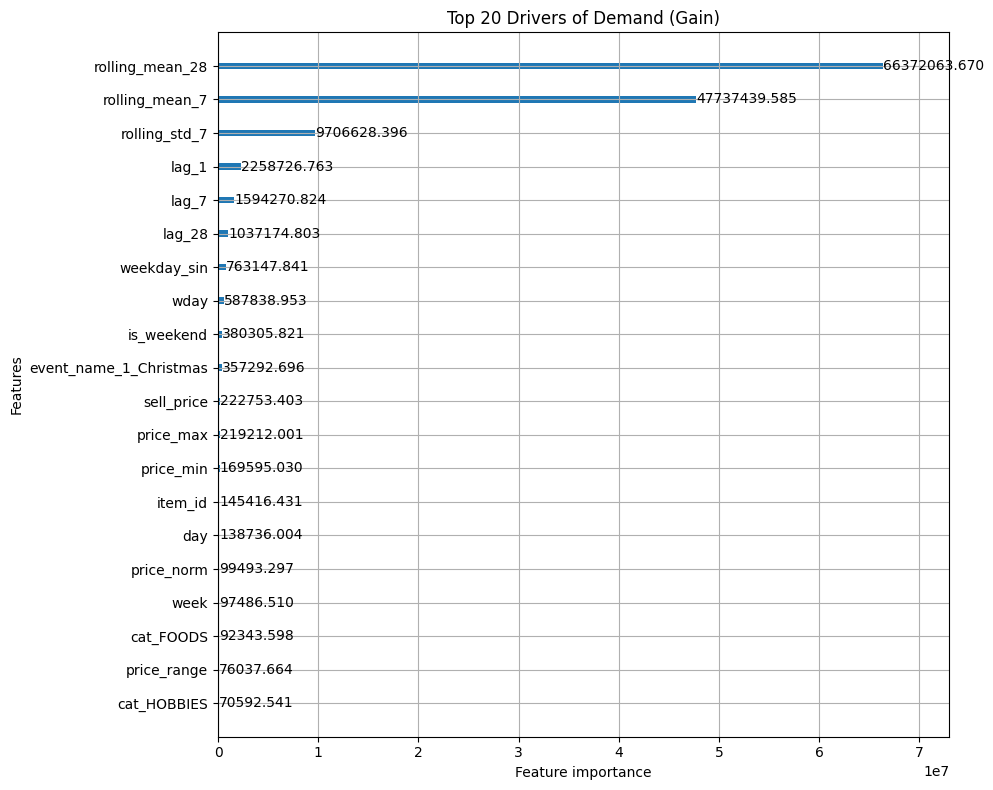

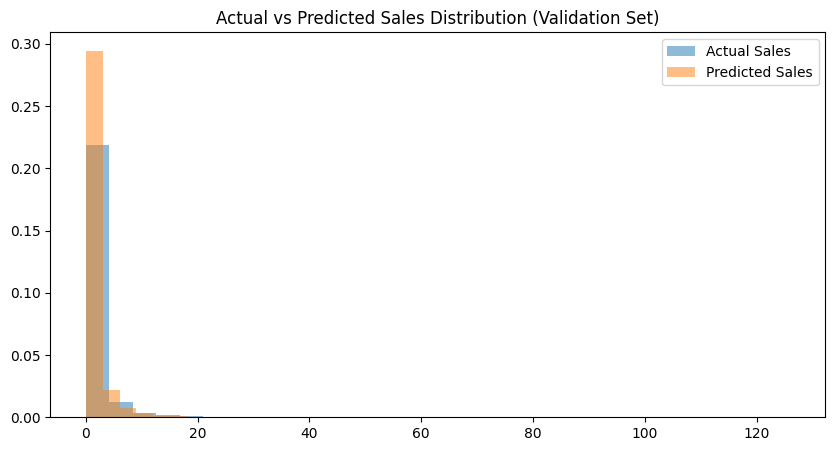

In [4]:
# Generate predictions on the validation set
y_pred = model.predict(X_val)

# Calculate Error Metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print(f"\n--- Model Performance ---")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE:  {mae:.4f}")

# Plot Top 20 Feature Importances
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, max_num_features=20, importance_type='gain', figsize=(10, 8))
plt.title("Top 20 Drivers of Demand (Gain)")
plt.tight_layout()
plt.show()

# Plot Actual vs Predicted Distribution (to see if we captured the spikes)
plt.figure(figsize=(10, 5))
plt.hist(y_val, bins=30, alpha=0.5, label='Actual Sales', density=True)
plt.hist(y_pred, bins=30, alpha=0.5, label='Predicted Sales', density=True)
plt.title("Actual vs Predicted Sales Distribution (Validation Set)")
plt.legend()
plt.show()

In [5]:
import os

# Ensure directory exists
os.makedirs("../models", exist_ok=True)

model_path = "../models/lgbm_forecasting_model.pkl"
joblib.dump(model, model_path)
print(f"\nModel successfully saved to {model_path}")


Model successfully saved to ../models/lgbm_forecasting_model.pkl
